In [1]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Feature Selection with Random Forest

In [17]:
# Setting y 
y_rsf_classifier = clinical_train['event_OS']

# Define parameters for StratifiedKFold
n_splits = 5
n_repeats = 4

# Initialize variables to store results
all_feature_importances = []

# Perform stratified 5-split 4 times and train Random Forest Classifier for each split
for i in range(n_repeats):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=i)  # Use different random_state for each repeat
    repeat_feature_importances = []
    
    for train_index, test_index in skf.split(X, y_rsf_classifier):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_rsf_classifier.iloc[train_index], y_rsf_classifier.iloc[test_index]

        # Train Random Forest Classifier
        rf_classifier = RandomForestClassifier(random_state=i)  # You can adjust parameters as needed
        rf_classifier.fit(X_train, y_train)

        # Store feature importances
        repeat_feature_importances.append(rf_classifier.feature_importances_)

    all_feature_importances.append(repeat_feature_importances)

# Convert to numpy array for easier manipulation
all_feature_importances = np.array(all_feature_importances)

# Sum feature importances across repeats and folds
sum_feature_importances = np.sum(all_feature_importances, axis=(0, 1))

# Get feature names
feature_names = list(X)

# Create a DataFrame
df_feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance_Sum': sum_feature_importances})

# Sort feature importances by their sum
df_feature_importances_sorted = df_feature_importances.sort_values(by='Importance_Sum', ascending=False)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

...

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using Random Forest Classifier')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

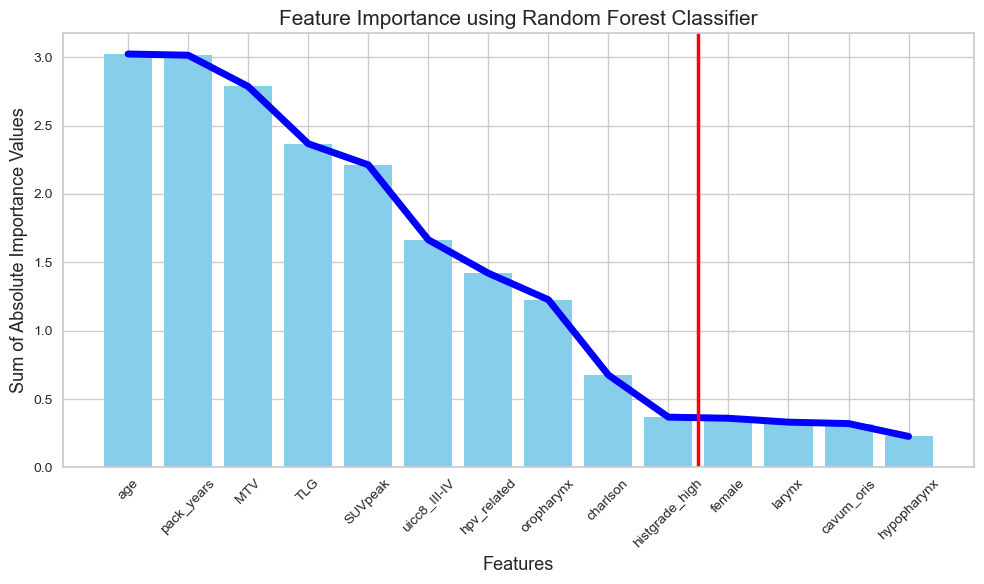

In [26]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(df_feature_importances_sorted['Feature'], 
        df_feature_importances_sorted['Importance_Sum'], 
        color='skyblue')
plt.plot(df_feature_importances_sorted['Feature'], 
         df_feature_importances_sorted['Importance_Sum'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using Random Forest Classifier', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=9.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [27]:
selected_features = df_feature_importances_sorted[0:10]['Feature']

In [28]:
selected_features

0                age
9         pack_years
12               MTV
13               TLG
11           SUVpeak
10      uicc8_III-IV
7        hpv_related
3         oropharynx
8           charlson
6     histgrade_high
Name: Feature, dtype: object

In [29]:
X_rf = X[selected_features]
X_new = X_rf.copy() 

X_MAASTRO_rf = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_rf.copy()

# Standardization

In [30]:
original_X = X.copy()

In [31]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [32]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [33]:
X_new

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,54.238356,0.000000,7.934,86.228420,14.473272,0.0,0.0,1,0,1
1,54.539726,27.404795,1.656,7.040100,5.044678,0.0,0.0,0,1,0
2,59.019178,41.019178,14.502,83.569669,7.839043,1.0,0.0,0,1,1
3,70.726027,37.500000,2.440,5.567091,2.880631,0.0,0.0,0,1,0
4,67.865753,53.000000,3.668,16.150550,5.402006,0.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
134,60.435616,0.000000,3.650,26.280140,9.290139,0.0,1.0,1,0,1
135,68.794521,0.000000,18.967,101.754834,7.172883,1.0,1.0,1,0,1
136,57.498630,39.498630,6.370,66.273201,13.873187,0.0,1.0,1,1,1
137,65.684932,71.527397,12.443,71.832443,7.507419,1.0,1.0,1,1,1


In [34]:
X_new_std

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,-0.776210,-1.101176,-0.296907,-0.179158,0.646616,0.0,0.0,1,0,1
1,-0.737256,0.105775,-0.763433,-0.587333,-1.098689,0.0,0.0,0,1,0
2,-0.158251,0.705374,0.191169,-0.192863,-0.581431,1.0,0.0,0,1,1
3,1.354953,0.550384,-0.705173,-0.594926,-1.499271,0.0,0.0,0,1,0
4,0.985240,1.233028,-0.613919,-0.540373,-1.032545,0.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
134,0.024835,-1.101176,-0.615257,-0.488161,-0.312822,0.0,1.0,1,0,1
135,1.105290,-1.101176,0.522969,-0.099128,-0.704742,1.0,1.0,1,0,1
136,-0.354794,0.638406,-0.413130,-0.282017,0.535536,0.0,1.0,1,1,1
137,0.703351,2.049005,0.038162,-0.253362,-0.642817,1.0,1.0,1,1,1


In [35]:
MAASTRO_new

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,55,0,22.841,263.611623,15.438583,0,1,1,1,1
1,55,20,5.660,36.980700,8.829353,1,0,1,0,0
2,55,6,7.791,74.636342,13.476123,1,0,1,1,0
3,61,45,7.908,46.791979,8.632732,1,0,0,1,1
4,70,59,15.237,107.637514,9.783954,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
94,66,55,6.110,144.490782,31.338410,1,0,0,0,0
95,63,174,7.182,69.214868,13.041604,1,0,0,1,0
96,63,0,16.483,102.594274,8.944517,1,1,1,1,1
97,54,0,9.981,103.229492,14.184236,0,1,1,0,1


In [36]:
MAASTRO_new_std

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,-0.677762,-1.101176,0.810851,0.735160,0.825303,0,1,1,1,1
1,-0.677762,-0.220344,-0.465891,-0.433005,-0.398117,1,0,1,0,0
2,-0.677762,-0.836927,-0.307534,-0.238909,0.462036,1,0,1,1,0
3,0.097786,0.880696,-0.298839,-0.382433,-0.434513,1,0,0,1,1
4,1.261108,1.497278,0.245788,-0.068806,-0.221413,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
94,0.744076,1.321112,-0.432451,0.121154,3.768483,1,0,0,0,0
95,0.356302,6.562062,-0.352789,-0.266854,0.381603,1,0,0,1,0
96,0.356302,-1.101176,0.338380,-0.094801,-0.376799,1,1,1,1,1
97,-0.807020,-1.101176,-0.144792,-0.091527,0.593113,0,1,1,0,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [37]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:52:28,815] A new study created in memory with name: no-name-5b323749-8cb5-4c5c-b47c-4f9dc5ee8b6c


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7229437229437229
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8186274509803921
Fold 4 C-index: 0.8270042194092827


[I 2024-04-13 23:52:50,159] A new study created in memory with name: no-name-c128fd93-dfcb-40f3-ac4e-64adddeed567


Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:52:50,137] Trial 0 finished with value: 0.7605276205848553 and parameters: {}. Best is trial 0 with value: 0.7605276205848553.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7605276205848553], datetime_start=datetime.datetime(2024, 4, 13, 23, 52, 29, 264591), datetime_complete=datetime.datetime(2024, 4, 13, 23, 52, 50, 134627), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7605276205848553


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1856451490885867
Fold 2 IBS: 0.18524473029686647
Fold 3 IBS: 0.15584670448240037
Fold 4 IBS: 0.1380987659343816
Fold 5 IBS: 0.27557203064084473
[I 2024-04-13 23:52:51,495] Trial 0 finished with value: 0.18808147608861597 and parameters: {}. Best is trial 0 with value: 0.18808147608861597.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18808147608861597], datetime_start=datetime.datetime(2024, 4, 13, 23, 52, 50, 270189), datetime_complete=datetime.datetime(2024, 4, 13, 23, 52, 51, 495699), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18808147608861597


In [38]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.761
train_ibs:  0.188


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.606
IBS score: 0.291


In [42]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [43]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [44]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:52:52,147] A new study created in memory with name: no-name-80f326b2-3ebe-452e-9073-e7a1eecc7252


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6212121212121212
Fold 2 C-index: 0.6383928571428571
Fold 3 C-index: 0.7720588235294118
Fold 4 C-index: 0.8037974683544303


[I 2024-04-13 23:52:52,834] A new study created in memory with name: no-name-eab1d3f8-350d-48fe-8369-3a577d71e0e5


Fold 5 C-index: 0.5633802816901409
[I 2024-04-13 23:52:52,827] Trial 0 finished with value: 0.6797683103857922 and parameters: {}. Best is trial 0 with value: 0.6797683103857922.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6797683103857922], datetime_start=datetime.datetime(2024, 4, 13, 23, 52, 52, 351250), datetime_complete=datetime.datetime(2024, 4, 13, 23, 52, 52, 826656), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6797683103857922


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651674697235
Fold 2 IBS: 0.22157791016872225
Fold 3 IBS: 0.20453594089893293
Fold 4 IBS: 0.2247380328252742
Fold 5 IBS: 0.21812431423859643
[I 2024-04-13 23:52:53,504] Trial 0 finished with value: 0.21659054297569963 and parameters: {}. Best is trial 0 with value: 0.21659054297569963.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054297569963], datetime_start=datetime.datetime(2024, 4, 13, 23, 52, 52, 874354), datetime_complete=datetime.datetime(2024, 4, 13, 23, 52, 53, 504704), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054297569963


In [45]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [46]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.68
train_ibs:  0.217


#### Test

In [47]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [48]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.534


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [49]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [50]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:52:54,197] A new study created in memory with name: no-name-7dba6f75-ba34-452e-816d-07c2e57e53bd


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839


[I 2024-04-13 23:52:55,803] A new study created in memory with name: no-name-c6e2ada1-354b-465b-8835-f4ce611fc719


Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:52:55,791] Trial 0 finished with value: 0.7675569743286542 and parameters: {}. Best is trial 0 with value: 0.7675569743286542.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7675569743286542], datetime_start=datetime.datetime(2024, 4, 13, 23, 52, 54, 252237), datetime_complete=datetime.datetime(2024, 4, 13, 23, 52, 55, 791145), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7675569743286542


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.18598779025052353
Fold 2 IBS: 0.18316084153693504
Fold 3 IBS: 0.15507898141887433
Fold 4 IBS: 0.13668431803021872
Fold 5 IBS: 0.27281712587033224
[I 2024-04-13 23:52:57,490] Trial 0 finished with value: 0.18674581142137678 and parameters: {}. Best is trial 0 with value: 0.18674581142137678.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18674581142137678], datetime_start=datetime.datetime(2024, 4, 13, 23, 52, 56, 68635), datetime_complete=datetime.datetime(2024, 4, 13, 23, 52, 57, 489787), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18674581142137678


In [51]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [52]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.768
train_ibs:  0.187


#### Test

In [53]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [54]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.609


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.287


In [55]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [56]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:52:58,835] A new study created in memory with name: no-name-6d315984-8934-42c2-b621-68726fda94cc


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:53:01,655] Trial 0 finished with value: 0.7666911734628534 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7666911734628534.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:53:03,650] Trial 1 finished with value: 0.7657983163199963 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7666911734628534.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:53:05,147] Trial 2 finished with value: 0.7657983163199963 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with 

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:53:40,447] Trial 24 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.906589830664419}. Best is trial 4 with value: 0.7675569743286542.
Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:53:42,723] Trial 25 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.8858855583070442}. Best is trial 4 with value: 0.7675569743286542.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.6294642857142857
Fold 3 C-index: 0.7598039215686274
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.5915492957746479
[I 2024-04-13 23:53:43,819] Trial 26 finished with value: 0.6862615881779541 and parameters: {'l1_ratio': 0.015423757551295547

Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:54:44,151] Trial 48 finished with value: 0.7666911734628534 and parameters: {'l1_ratio': 0.6521280584688621}. Best is trial 4 with value: 0.7675569743286542.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:54:47,041] Trial 49 finished with value: 0.7657983163199963 and parameters: {'l1_ratio': 0.22247373808437249}. Best is trial 4 with value: 0.7675569743286542.
Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:54:50,384] Trial 50 finished with value: 0.7675569743286542 and parameters: {'l1_ratio': 0.799730492499605}. Best is t

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.1860871516928707
Fold 2 IBS: 0.1835640101948131
Fold 3 IBS: 0.1549779370675862
Fold 4 IBS: 0.13662325714844176
Fold 5 IBS: 0.27248387068586266
[I 2024-04-13 23:56:44,133] Trial 0 finished with value: 0.1867472453579149 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.1867472453579149.
Fold 1 IBS: 0.1863228309211684
Fold 2 IBS: 0.18441210818633466
Fold 3 IBS: 0.15480433204166522
Fold 4 IBS: 0.13663768295370624
Fold 5 IBS: 0.2724489618055874
[I 2024-04-13 23:56:46,221] Trial 1 finished with value: 0.18692518318169238 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.1867472453579149.
Fold 1 IBS: 0.18630904844245055
Fold 2 IBS: 0.18461220124234815
Fold 3 IBS: 0.15482214048415427
Fold 4 IBS: 0.13658927950508873
Fold 5 IBS: 0.27226248899833455
[I 2024-04-13 23:56:48,664] Trial 2 finished with value: 0.18691903173447524 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.1867472453579149.

Fold 1 IBS: 0.18601551750036352
Fold 2 IBS: 0.18317977956196696
Fold 3 IBS: 0.15503194720723576
Fold 4 IBS: 0.13667890297262983
Fold 5 IBS: 0.2726437973674772
[I 2024-04-13 23:57:34,453] Trial 25 finished with value: 0.18670998892193466 and parameters: {'l1_ratio': 0.8963267675023483}. Best is trial 25 with value: 0.18670998892193466.
Fold 1 IBS: 0.18600437162926242
Fold 2 IBS: 0.1831755884766803
Fold 3 IBS: 0.15504901186869097
Fold 4 IBS: 0.13670198686156634
Fold 5 IBS: 0.2727206948900025
[I 2024-04-13 23:57:37,108] Trial 26 finished with value: 0.1867303307452405 and parameters: {'l1_ratio': 0.9136862621457851}. Best is trial 25 with value: 0.18670998892193466.
Fold 1 IBS: 0.18607630700872177
Fold 2 IBS: 0.18339005325062
Fold 3 IBS: 0.15499520649328036
Fold 4 IBS: 0.13660167111827604
Fold 5 IBS: 0.2725364612610173
[I 2024-04-13 23:57:39,221] Trial 27 finished with value: 0.1867199398263831 and parameters: {'l1_ratio': 0.7590691036030236}. Best is trial 25 with value: 0.18670998892193

Fold 1 IBS: 0.1863573877616958
Fold 2 IBS: 0.18454552136477104
Fold 3 IBS: 0.15483770296188143
Fold 4 IBS: 0.13661303306920472
Fold 5 IBS: 0.272323397144691
[I 2024-04-13 23:58:35,697] Trial 50 finished with value: 0.18693540846044882 and parameters: {'l1_ratio': 0.2311229033161103}. Best is trial 47 with value: 0.1866959375171148.
Fold 1 IBS: 0.1860164851491982
Fold 2 IBS: 0.1831801405741309
Fold 3 IBS: 0.15503034630310022
Fold 4 IBS: 0.13667690143754047
Fold 5 IBS: 0.2726371275547876
[I 2024-04-13 23:58:38,701] Trial 51 finished with value: 0.1867082002037515 and parameters: {'l1_ratio': 0.89484936499899}. Best is trial 47 with value: 0.1866959375171148.
Fold 1 IBS: 0.18601490818483143
Fold 2 IBS: 0.1831705814460952
Fold 3 IBS: 0.15503416117383498
Fold 4 IBS: 0.1366268844178051
Fold 5 IBS: 0.272887644210899
[I 2024-04-13 23:58:41,571] Trial 52 finished with value: 0.18674683588669314 and parameters: {'l1_ratio': 0.9542805525857302}. Best is trial 47 with value: 0.1866959375171148.
Fo

Fold 1 IBS: 0.18601881766486514
Fold 2 IBS: 0.18318100892968953
Fold 3 IBS: 0.15502648986208684
Fold 4 IBS: 0.1366720783957407
Fold 5 IBS: 0.27262105401220177
[I 2024-04-13 23:59:55,611] Trial 75 finished with value: 0.1867038897729168 and parameters: {'l1_ratio': 0.8913071253210754}. Best is trial 47 with value: 0.1866959375171148.
Fold 1 IBS: 0.18602642800195643
Fold 2 IBS: 0.1831838154394477
Fold 3 IBS: 0.15501393229684213
Fold 4 IBS: 0.13665635844035656
Fold 5 IBS: 0.2728318851083523
[I 2024-04-13 23:59:58,634] Trial 76 finished with value: 0.18674248385739103 and parameters: {'l1_ratio': 0.8799336571708656}. Best is trial 47 with value: 0.1866959375171148.
Fold 1 IBS: 0.18599042495708468
Fold 2 IBS: 0.18316353976327218
Fold 3 IBS: 0.15507456970940092
Fold 4 IBS: 0.13667886052854794
Fold 5 IBS: 0.2727988436455526
[I 2024-04-14 00:00:02,202] Trial 77 finished with value: 0.18674124772077166 and parameters: {'l1_ratio': 0.9954887251217412}. Best is trial 47 with value: 0.186695937517

In [57]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [58]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.768
train_ibs:  0.187


#### Test

In [59]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [60]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.7194970228885845)

test_cindex : 0.61


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.8847849969773163)

test_ibs:  0.287


In [61]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [62]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:01:16,813] A new study created in memory with name: no-name-55bf008e-d1ae-4e6f-87f2-d913d8e62c2b


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7532467532467533
Fold 2 C-index: 0.6339285714285714
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8544303797468354
Fold 5 C-index: 0.636150234741784
[I 2024-04-14 00:01:34,548] Trial 0 finished with value: 0.7363355015582791 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7363355015582791.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8523206751054853
Fold 5 C-index: 0.647887323943662
[I 2024-04-14 00:01:47,593] Trial 1 finished with value: 0.7384774286868347 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max

Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.704225352112676
[I 2024-04-14 00:04:45,200] Trial 15 finished with value: 0.7926763351493695 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 483, 'oob_score': True, 'max_samples': 0.9915936271771615, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 15 with value: 0.7926763351493695.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.8169642857142857
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.704225352112676
[I 2024-04-14 00:04:56,808] Trial 16 finished with value: 0.7970594520324864 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 2, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.9632019382250055, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.075649367762977

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.7183098591549296
[I 2024-04-14 00:06:12,066] Trial 30 finished with value: 0.793378072310303 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 4, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 85, 'oob_score': True, 'max_samples': 0.8295636627924149, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.03737500582975329, 'warm_start': True}. Best is trial 25 with value: 0.810205399401531.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8839662447257384
Fold 5 C-index: 0.7089201877934272
[I 2024-04-14 00:06:17,603] Trial 31 finished with value: 0.7957895350396111 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 230, 'oob_score': True, 'max_samples': 0.8698146012029154, '

...

Fold 5 IBS: 0.22664902658714126
[I 2024-04-14 00:38:30,126] Trial 31 finished with value: 0.18664402376401593 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 293, 'oob_score': False, 'max_samples': 0.760076202384518, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.12053440019786568}. Best is trial 25 with value: 0.18541060533130255.
Fold 1 IBS: 0.17924391428026357
Fold 2 IBS: 0.21580555805224105
Fold 3 IBS: 0.16169962680759295
Fold 4 IBS: 0.1473771359605064
Fold 5 IBS: 0.22270811223488068
[I 2024-04-14 00:38:47,129] Trial 32 finished with value: 0.18536686946709696 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 367, 'oob_score': False, 'max_samples': 0.6195244229601323, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.10211517213176136}. Best is trial 32 with value: 0.18536686946709696.
Fold 1 IBS: 0.17986602186177758
Fold 2 IBS: 0.21

Fold 1 IBS: 0.17739465038110155
Fold 2 IBS: 0.21276243506490725
Fold 3 IBS: 0.16160555782186015
Fold 4 IBS: 0.14311242513123648
Fold 5 IBS: 0.22197207125200943
[I 2024-04-14 00:40:13,832] Trial 47 finished with value: 0.18336942793022298 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 11, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 91, 'oob_score': True, 'max_samples': 0.5030079701115354, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.06742576372903179}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17817455766126414
Fold 2 IBS: 0.2056142320761358
Fold 3 IBS: 0.17136980731682958
Fold 4 IBS: 0.1517629787282082
Fold 5 IBS: 0.2158509318926223
[I 2024-04-14 00:40:16,246] Trial 48 finished with value: 0.18455450153501202 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 40, 'oob_score': True, 'max_samples': 0.45113067734816487, 'max_features': 'auto', 'min_weight_fraction_leaf

Fold 1 IBS: 0.18021371373261355
Fold 2 IBS: 0.20276408785346708
Fold 3 IBS: 0.1649417152136776
Fold 4 IBS: 0.15142221337436843
Fold 5 IBS: 0.21894260849421615
[I 2024-04-14 00:41:26,608] Trial 63 finished with value: 0.18365686773366857 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 4, 'min_samples_leaf': 10, 'max_depth': 6, 'n_estimators': 96, 'oob_score': True, 'max_samples': 0.595897376295266, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.012492189362659112}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17901142015584834
Fold 2 IBS: 0.21784040587874096
Fold 3 IBS: 0.16088565909392738
Fold 4 IBS: 0.14287077029960885
Fold 5 IBS: 0.22469333583962847
[I 2024-04-14 00:41:33,346] Trial 64 finished with value: 0.1850603182535508 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 6, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 135, 'oob_score': True, 'max_samples': 0.6542957469639504, 'max_features': 'sqrt', 'min_weight_fraction_lea

Fold 1 IBS: 0.1846630295744542
Fold 2 IBS: 0.2094063233794573
Fold 3 IBS: 0.1725928631353916
Fold 4 IBS: 0.16850815329771193
Fold 5 IBS: 0.21861719205278374
[I 2024-04-14 00:42:53,813] Trial 79 finished with value: 0.19075751228795976 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 11, 'max_depth': 7, 'n_estimators': 85, 'oob_score': True, 'max_samples': 0.6691101514115952, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07379564215435265}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.1806562415271345
Fold 2 IBS: 0.2149229351576256
Fold 3 IBS: 0.1619331641155935
Fold 4 IBS: 0.1482603925846792
Fold 5 IBS: 0.22381820855608095
[I 2024-04-14 00:43:02,471] Trial 80 finished with value: 0.18591818838822274 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 6, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 193, 'oob_score': True, 'max_samples': 0.575453026455684, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.

Fold 1 IBS: 0.18067051892997218
Fold 2 IBS: 0.20976917694401034
Fold 3 IBS: 0.1627021515583648
Fold 4 IBS: 0.15155219149304505
Fold 5 IBS: 0.22007018815890209
[I 2024-04-14 00:44:04,630] Trial 95 finished with value: 0.1849528454168589 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 7, 'n_estimators': 132, 'oob_score': True, 'max_samples': 0.4847998384701818, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07698922447900798}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17653837850706317
Fold 2 IBS: 0.21665820235713712
Fold 3 IBS: 0.15925978769855675
Fold 4 IBS: 0.1361996911640683
Fold 5 IBS: 0.22133644256987917
[I 2024-04-14 00:44:09,571] Trial 96 finished with value: 0.1819985004593409 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 100, 'oob_score': True, 'max_samples': 0.6411081762780679, 'max_features': 'sqrt', 'min_weight_fraction_leaf'

In [63]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [64]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.867
train_ibs:  0.181


#### Test

In [65]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [66]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=13, max_leaf_nodes=12,
                     max_samples=0.8731189968319242, min_samples_leaf=2,
                     min_samples_split=7,
                     min_weight_fraction_leaf=0.012901666963593935,
                     n_estimators=393, random_state=123, warm_start=True)

test_cindex:  0.68


RandomSurvivalForest(max_depth=9, max_leaf_nodes=4,
                     max_samples=0.6434896963800851, min_samples_leaf=6,
                     min_samples_split=16,
                     min_weight_fraction_leaf=0.008689309516786857,
                     n_estimators=93, oob_score=True, random_state=123)

test_ibs:  0.204


In [67]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [68]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:44:28,438] A new study created in memory with name: no-name-0e6c328f-8358-4f2f-9344-5494428c633b


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.8431372549019608
Fold 4 C-index: 0.8523206751054853
Fold 5 C-index: 0.6948356807511737
[I 2024-04-14 00:44:31,238] Trial 0 finished with value: 0.7824959515889536 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7824959515889536.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:44:38,243] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8164556962025317
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:46:01,434] Trial 16 finished with value: 0.7674928647450487 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.7926307801682724.
Fold 1 C-index: 0.7727272727272727
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8161764705882353
Fold 4 C-index: 0.8164556962025317
Fold 5 C-index: 0.6384976525821596
[I 2024-04-14 00:46:04,671] Trial 17 finished with value: 0.7659142755628969 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.8348214285714286
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8565400843881856
Fold 5 C-index: 0.7089201877934272
[I 2024-04-14 00:47:07,025] Trial 31 finished with value: 0.797945313921935 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 467, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9286371142434082, 'min_weight_fraction_leaf': 0.043457520259011145}. Best is trial 31 with value: 0.797945313921935.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.704225352112676
[I 2024-04-14 00:47:10,961] Trial 32 finished with value: 0.7953456393497609 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 412, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.1700519965855827
Fold 2 IBS: 0.21054009443018218
Fold 3 IBS: 0.16719925029759086
Fold 4 IBS: 0.1613089358324982
Fold 5 IBS: 0.23161013296531519
[I 2024-04-14 00:56:23,574] Trial 30 finished with value: 0.18814208202223381 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 231, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5014558998220808, 'min_weight_fraction_leaf': 0.07553984363425942}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.17216923621723923
Fold 2 IBS: 0.2108044066276367
Fold 3 IBS: 0.16702564967756997
Fold 4 IBS: 0.16193700192755658
Fold 5 IBS: 0.22777679864148306
[I 2024-04-14 00:56:27,888] Trial 31 finished with value: 0.18794261861829709 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 104, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.50

Fold 1 IBS: 0.17435639182974702
Fold 2 IBS: 0.20994478059366992
Fold 3 IBS: 0.17390642939991824
Fold 4 IBS: 0.15611012586331807
Fold 5 IBS: 0.23484087328723918
[I 2024-04-14 00:57:28,391] Trial 45 finished with value: 0.18983172019477848 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 7, 'n_estimators': 30, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.36358160358674346, 'min_weight_fraction_leaf': 0.019139627806960186}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.16982796418539936
Fold 2 IBS: 0.2051095587601829
Fold 3 IBS: 0.16744029805038804
Fold 4 IBS: 0.16614272074156763
Fold 5 IBS: 0.2257030535974815
[I 2024-04-14 00:57:31,626] Trial 46 finished with value: 0.1868447190670039 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 10, 'max_depth': 2, 'n_estimators': 83, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.52

Fold 1 IBS: 0.16765519376833984
Fold 2 IBS: 0.21338935024041344
Fold 3 IBS: 0.16485157739969006
Fold 4 IBS: 0.15053829791384152
Fold 5 IBS: 0.23475096475779542
[I 2024-04-14 00:59:01,451] Trial 60 finished with value: 0.18623707681601606 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 248, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7515269679411078, 'min_weight_fraction_leaf': 0.0331030054971697}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.1680473256730751
Fold 2 IBS: 0.21133389100118852
Fold 3 IBS: 0.16515345727901012
Fold 4 IBS: 0.15059428998658445
Fold 5 IBS: 0.23565505113617552
[I 2024-04-14 00:59:10,085] Trial 61 finished with value: 0.1861568030152067 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 225, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.761016

Fold 1 IBS: 0.17259670656908646
Fold 2 IBS: 0.21818838399873644
Fold 3 IBS: 0.16452180367563315
Fold 4 IBS: 0.15183007751790134
Fold 5 IBS: 0.24105979875791303
[I 2024-04-14 01:01:28,427] Trial 75 finished with value: 0.18963935410385407 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 12, 'min_samples_leaf': 1, 'max_depth': 5, 'n_estimators': 173, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7036897052631409, 'min_weight_fraction_leaf': 0.061934596197347286}. Best is trial 68 with value: 0.18519930021630024.
Fold 1 IBS: 0.17049974316232996
Fold 2 IBS: 0.21021282137570835
Fold 3 IBS: 0.171725346934489
Fold 4 IBS: 0.16993046099944767
Fold 5 IBS: 0.22486721791680528
[I 2024-04-14 01:01:36,653] Trial 76 finished with value: 0.18944711807775605 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 5, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 214, 'oob_score': True, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.1663533549271886
Fold 2 IBS: 0.2150071794842812
Fold 3 IBS: 0.16079786805569013
Fold 4 IBS: 0.14787623402213085
Fold 5 IBS: 0.23479337027361627
[I 2024-04-14 01:03:21,004] Trial 90 finished with value: 0.18496560135258142 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 157, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8849026790155812, 'min_weight_fraction_leaf': 0.017295283166596138}. Best is trial 90 with value: 0.18496560135258142.
Fold 1 IBS: 0.16759010491213924
Fold 2 IBS: 0.2151914874280737
Fold 3 IBS: 0.1620018099937226
Fold 4 IBS: 0.14877281905345466
Fold 5 IBS: 0.2340529034619089
[I 2024-04-14 01:03:27,949] Trial 91 finished with value: 0.1855218249698598 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 168, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.88399

In [69]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [70]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.814
train_ibs:  0.184


#### Test

In [71]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [72]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=11, max_features=None, max_leaf_nodes=12,
                   max_samples=0.9744075181519277, min_samples_leaf=1,
                   min_samples_split=18,
                   min_weight_fraction_leaf=0.0008190349739849552,
                   n_estimators=306, random_state=123, warm_start=True)

C-index score: 0.613


ExtraSurvivalTrees(max_depth=12, max_features='log2', max_leaf_nodes=5,
                   max_samples=0.9255044252610253, min_samples_leaf=1,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.014356295713664476,
                   n_estimators=132, oob_score=True, random_state=123,
                   warm_start=True)

IBS: 0.219


In [73]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [74]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 01:04:11,521] A new study created in memory with name: no-name-8213cb87-a47b-43d1-a4fb-d63a5e2ced19


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:05:05,108] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:05:35,578] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:20:14,936] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7334874350516556.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:22:01,536] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:40:16,066] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7334874350516556.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5558035714285714
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 01:42:15,826] Trial 26 finished with value: 0.5332264419852447 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446,

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 04:59:40,001] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9027683411994925, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.13472529918097312, 'n_estimators': 381, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.36938177041618503, 'max_features': 'auto', 'min_impurity_decrease': 1.1016843774656315e-07, 'validation_fraction': 0.898549324711475, 'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 12, 'max_depth': 3}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:01:47,331] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.8324789538052517, 'learning_rate': 0.0985092209

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:30:52,529] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.008782667792366316, 'dropout_rate': 0.12972298735589705, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.7134499429690735, 'min_weight_fraction_leaf': 0.19311178079767077, 'max_features': 'log2', 'min_impurity_decrease': 1.142816958470248e-06, 'validation_fraction': 0.9729459657934212, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 4}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:33:21,089] Trial 67 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.8640185330574577, 'learning_rate': 0.01599734708

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:55:38,583] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.05776064499915696, 'dropout_rate': 0.2556920821676466, 'n_estimators': 442, 'criterion': 'squared_error', 'ccp_alpha': 0.5896250392603071, 'min_weight_fraction_leaf': 0.22988050749684658, 'max_features': 1, 'min_impurity_decrease': 1.4995945809430595e-05, 'validation_fraction': 0.8950354974332698, 'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 3}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 05:58:36,285] Trial 78 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7443996478445325, 'learning_rate': 0.0869328686638194

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 06:23:31,214] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8800231052433968, 'learning_rate': 0.015424283294721588, 'dropout_rate': 0.20093805843087115, 'n_estimators': 390, 'criterion': 'squared_error', 'ccp_alpha': 1.351539840282731, 'min_weight_fraction_leaf': 0.28958635214901884, 'max_features': 'auto', 'min_impurity_decrease': 2.329078771156988e-07, 'validation_fraction': 0.939344740485312, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 4}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 06:25:41,956] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9819209167757807, 'learning_rate': 0.02021924169671

Fold 3 IBS: 0.20326835306857854
Fold 4 IBS: 0.22293987983911168
Fold 5 IBS: 0.21780855087220638
[I 2024-04-14 06:51:40,603] Trial 99 finished with value: 0.21547384259631083 and parameters: {'subsample': 0.24286963781937687, 'learning_rate': 0.01358129947690588, 'dropout_rate': 0.25496540816023416, 'n_estimators': 454, 'criterion': 'squared_error', 'ccp_alpha': 0.004367160733265784, 'min_weight_fraction_leaf': 0.2624099419664444, 'max_features': 'auto', 'min_impurity_decrease': 5.321953542697131e-07, 'validation_fraction': 0.9620562032012763, 'min_samples_split': 11, 'max_leaf_nodes': 20, 'min_samples_leaf': 10, 'max_depth': 1}. Best is trial 53 with value: 0.2150432178150902.


* Best trial for IBS: 
 FrozenTrial(number=53, state=TrialState.COMPLETE, values=[0.2150432178150902], datetime_start=datetime.datetime(2024, 4, 14, 4, 52, 29, 261192), datetime_complete=datetime.datetime(2024, 4, 14, 4, 54, 58, 174017), params={'subsample': 0.9101431135071837, 'learning_rate': 0.01542077249045

In [75]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [76]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.745
train_ibs:  0.215


#### Test

In [77]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [78]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03063070291051248,
                                 criterion='squared_error',
                                 dropout_rate=0.2576884847115747,
                                 learning_rate=0.007359366951045268,
                                 max_depth=16, max_features=1,
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=1.3903906488794697e-07,
                                 min_samples_leaf=14, min_samples_split=20,
                                 min_weight_fraction_leaf=0.38180626899357545,
                                 n_estimators=96, random_state=123,
                                 subsample=0.8938290428827321,
                                 validation_fraction=0.9577535215137098)

C-index score: 0.605


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009625013743012712,
                                 criterion='squared_error',
                                 dropout_rate=0.1897783294507234,
                                 learning_rate=0.015420772490455037,
                                 max_features='auto', max_leaf_nodes=14,
                                 min_impurity_decrease=5.869825897765074e-07,
                                 min_samples_leaf=13, min_samples_split=20,
                                 min_weight_fraction_leaf=0.29880213170319914,
                                 n_estimators=430, random_state=123,
                                 subsample=0.9101431135071837,
                                 validation_fraction=0.9964423942006735)

IBS: 0.22


In [79]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [80]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:52:04,265] A new study created in memory with name: no-name-069dc9a0-be34-423b-a86c-5b2b46340db6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7549019607843137
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5938967136150235
[I 2024-04-14 06:52:06,300] Trial 0 finished with value: 0.7006175901048113 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7006175901048113.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5985915492957746
[I 2024-04-14 06:52:20,515] Trial 1 finished with value: 0.699595772927236 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.7006175901048113.
Fold 1 C-index: 0.7445887445887446
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7671568627450981
Fold 4 C-index: 0.78902953586497

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7598039215686274
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5985915492957746
[I 2024-04-14 06:54:03,122] Trial 19 finished with value: 0.701644092254967 and parameters: {'subsample': 0.6457256401960624, 'dropout_rate': 0.7254192287154788, 'n_estimators': 131, 'learning_rate': 0.08697733590757546}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5845070422535211
[I 2024-04-14 06:54:10,569] Trial 20 finished with value: 0.7036416166168245 and parameters: {'subsample': 0.8986193768259231, 'dropout_rate': 0.18732898522307728, 'n_estimators': 317, 'learning_rate': 0.06551866052750378}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6473214285714286
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5892018779342723
[I 2024-04-14 06:55:58,791] Trial 38 finished with value: 0.7046681187669803 and parameters: {'subsample': 0.8078746525666788, 'dropout_rate': 0.15266630898677364, 'n_estimators': 180, 'learning_rate': 0.06028724397863987}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.7532467532467533
Fold 2 C-index: 0.6383928571428571
Fold 3 C-index: 0.7647058823529411
Fold 4 C-index: 0.7890295358649789
Fold 5 C-index: 0.5821596244131455
[I 2024-04-14 06:56:04,983] Trial 39 finished with value: 0.7055069306041352 and parameters: {'subsample': 0.4135044908822448, 'dropout_rate': 0.10196882902995949, 'n_estimators': 294, 'learning_rate': 0.01033884503473171}. Best is trial 15 with value: 0.7174862037474513.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7598039215686274
Fold 4 C-ind

...

Fold 2 IBS: 0.2030281787290655
Fold 3 IBS: 0.1750994030569828
Fold 4 IBS: 0.19328585032034615
Fold 5 IBS: 0.21814307224075255
[I 2024-04-14 07:03:14,089] Trial 19 finished with value: 0.19652434028684665 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 19 with value: 0.19652434028684665.
Fold 1 IBS: 0.19670891384068478
Fold 2 IBS: 0.20460390544410206
Fold 3 IBS: 0.17925662749133048
Fold 4 IBS: 0.19945412483408936
Fold 5 IBS: 0.2209799818656319
[I 2024-04-14 07:03:14,643] Trial 20 finished with value: 0.2002007106951677 and parameters: {'subsample': 0.1435040576337751, 'dropout_rate': 0.7933084651006226, 'n_estimators': 43, 'learning_rate': 0.04127909023805986}. Best is trial 19 with value: 0.19652434028684665.
Fold 1 IBS: 0.1978165282113557
Fold 2 IBS: 0.20371056503236332
Fold 3 IBS: 0.18315129632705462
Fold 4 IBS: 0.20318692357044413
Fold 5 IBS: 0.21745092435145094
[I 2024-04

Fold 2 IBS: 0.23419595489452
Fold 3 IBS: 0.16454451881169602
Fold 4 IBS: 0.14872248011637335
Fold 5 IBS: 0.26168506780135664
[I 2024-04-14 07:03:42,230] Trial 38 finished with value: 0.19990877439941374 and parameters: {'subsample': 0.1013464553344481, 'dropout_rate': 0.13272164755980653, 'n_estimators': 195, 'learning_rate': 0.03633331992718605}. Best is trial 31 with value: 0.19353173726890496.
Fold 1 IBS: 0.18175033939616803
Fold 2 IBS: 0.3133950937031401
Fold 3 IBS: 0.21438062878473543
Fold 4 IBS: 0.15204569232458565
Fold 5 IBS: 0.30827307744534327
[I 2024-04-14 07:03:44,285] Trial 39 finished with value: 0.2339689663307945 and parameters: {'subsample': 0.4386645564776548, 'dropout_rate': 0.30422248996194895, 'n_estimators': 159, 'learning_rate': 0.06892741183938003}. Best is trial 31 with value: 0.19353173726890496.
Fold 1 IBS: 0.193167969129466
Fold 2 IBS: 0.35620134372954665
Fold 3 IBS: 0.2501550202631049
Fold 4 IBS: 0.20721771056186478
Fold 5 IBS: 0.3338946417949923
[I 2024-04-

Fold 2 IBS: 0.22043841744135037
Fold 3 IBS: 0.16894904140270756
Fold 4 IBS: 0.18022916664417304
Fold 5 IBS: 0.23896755196106384
[I 2024-04-14 07:04:12,561] Trial 57 finished with value: 0.19858822485067118 and parameters: {'subsample': 0.3366912620023526, 'dropout_rate': 0.616909158106548, 'n_estimators': 169, 'learning_rate': 0.017868279660336113}. Best is trial 31 with value: 0.19353173726890496.
Fold 1 IBS: 0.2038675460543705
Fold 2 IBS: 0.20868919945673425
Fold 3 IBS: 0.18920072491265577
Fold 4 IBS: 0.20996570885714597
Fold 5 IBS: 0.21647414297600664
[I 2024-04-14 07:04:13,984] Trial 58 finished with value: 0.20563946445138265 and parameters: {'subsample': 0.15307241576209557, 'dropout_rate': 0.746563734003379, 'n_estimators': 120, 'learning_rate': 0.007744259116864776}. Best is trial 31 with value: 0.19353173726890496.
Fold 1 IBS: 0.17367046900517472
Fold 2 IBS: 0.26089767882877957
Fold 3 IBS: 0.18083271712724003
Fold 4 IBS: 0.1528040345442965
Fold 5 IBS: 0.27979636866572033
[I 20

Fold 2 IBS: 0.20315134786322794
Fold 3 IBS: 0.1789399385980555
Fold 4 IBS: 0.19652338103573128
Fold 5 IBS: 0.21852725596177483
[I 2024-04-14 07:04:49,201] Trial 76 finished with value: 0.19858545409234535 and parameters: {'subsample': 0.17746221863764836, 'dropout_rate': 0.34025970494086744, 'n_estimators': 43, 'learning_rate': 0.04090109181979308}. Best is trial 65 with value: 0.19297360488112905.
Fold 1 IBS: 0.17721578413056543
Fold 2 IBS: 0.23858649034102783
Fold 3 IBS: 0.1630454758440892
Fold 4 IBS: 0.16075780009912316
Fold 5 IBS: 0.2586662617628188
[I 2024-04-14 07:04:50,391] Trial 77 finished with value: 0.19965436243552487 and parameters: {'subsample': 0.21676021120256683, 'dropout_rate': 0.17629353184919394, 'n_estimators': 94, 'learning_rate': 0.056148785328908046}. Best is trial 65 with value: 0.19297360488112905.
Fold 1 IBS: 0.18820508625431603
Fold 2 IBS: 0.21862704801940638
Fold 3 IBS: 0.17576274304837788
Fold 4 IBS: 0.1876162767365481
Fold 5 IBS: 0.23729134417363687
[I 20

Fold 1 IBS: 0.17772057211697967
Fold 2 IBS: 0.23231556950837243
Fold 3 IBS: 0.16350255795763124
Fold 4 IBS: 0.1653777853821842
Fold 5 IBS: 0.2492613534196278
[I 2024-04-14 07:05:26,403] Trial 95 finished with value: 0.19763556767695906 and parameters: {'subsample': 0.1865922368218768, 'dropout_rate': 0.25158336856020813, 'n_estimators': 184, 'learning_rate': 0.02477796124371184}. Best is trial 65 with value: 0.19297360488112905.
Fold 1 IBS: 0.1764872191006075
Fold 2 IBS: 0.22742202265497524
Fold 3 IBS: 0.16161191682379136
Fold 4 IBS: 0.16625240550255913
Fold 5 IBS: 0.24742820289783504
[I 2024-04-14 07:05:27,877] Trial 96 finished with value: 0.19584035339595368 and parameters: {'subsample': 0.14649695742958083, 'dropout_rate': 0.3360656548154278, 'n_estimators': 128, 'learning_rate': 0.03575284963871543}. Best is trial 65 with value: 0.19297360488112905.
Fold 1 IBS: 0.18933574427815297
Fold 2 IBS: 0.20409805561819722
Fold 3 IBS: 0.17057203528082945
Fold 4 IBS: 0.18311887705372204
Fold 

In [81]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [82]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.717
train_ibs:  0.193


#### Test

In [83]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [84]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10006460023230275,
                                              learning_rate=0.08616677729964022,
                                              n_estimators=297,
                                              random_state=123,
                                              subsample=0.8897480564271555)

C-index score: 0.533


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.23342965017617331,
                                              learning_rate=0.04392113598296221,
                                              n_estimators=80, random_state=123,
                                              subsample=0.13505807202685524)

IBS: 0.255


In [85]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [86]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.867,1.0
ExtraSurvivalTrees,0.814,2.0
CoxLasso,0.768,3.5
CoxElastic,0.768,3.5
CoxPH,0.761,5.0
GradientBoosting,0.745,6.0
ComponentwiseGradientBoosting,0.717,7.0
CoxRidge,0.680,8.0


In [87]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.181,1.0
ExtraSurvivalTrees,0.184,2.0
CoxLasso,0.187,3.5
CoxElastic,0.187,3.5
CoxPH,0.188,5.0
ComponentwiseGradientBoosting,0.193,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [88]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.680,1.0
ExtraSurvivalTrees,0.613,2.0
CoxElastic,0.610,3.0
CoxLasso,0.609,4.0
CoxPH,0.606,5.0
GradientBoosting,0.605,6.0
CoxRidge,0.534,7.0
ComponentwiseGradientBoosting,0.533,8.0


In [89]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.204,1.0
ExtraSurvivalTrees,0.219,2.0
GradientBoosting,0.220,3.0
CoxRidge,0.221,4.0
ComponentwiseGradientBoosting,0.255,5.0
CoxLasso,0.287,6.5
CoxElastic,0.287,6.5
CoxPH,0.291,8.0


In [90]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/standard/rf/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

modified_file_names = ['d1_os_standard_rf_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [91]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
